In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import healpy as hp
from pathlib import Path

def find_repo_root(start: Path = Path.cwd()) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / '.git').exists():
            return parent
    return start

repo_root = find_repo_root()
os.chdir(repo_root)
print('Working dir:', repo_root)

Working dir: /home/julian/Documents/cmb-sbi-inference


In [2]:
from src.data import PlanckDataLoader
cov_bin, lmin, lmax, _, _, _, _, _, _ = PlanckDataLoader.load_planck_data()
cov_200 = PlanckDataLoader.expand_cov_to_200_bins(cov_bin, lmin, lmax, target_bins=200, jitter=1e-2)
print(lmin)
print(lmax)

/home/julian/miniconda3/envs/sbi_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([  32,   63,   94,  125,  156,  187,  218,  249,  280,  311,  342,  373,
         404,  435,  466,  497,  528,  559,  590,  621,  652,  683,  714,  745,
         776,  807,  838,  869,  900,  931,  962,  993, 1024, 1055, 1086, 1117,
        1148, 1179, 1210, 1241, 1272, 1303, 1334, 1365, 1396, 1427, 1458, 1489,
        1520, 1551, 1582, 1613, 1644, 1675, 1706, 1737, 1768, 1799, 1830, 1861,
        1892, 1923, 1954, 1985, 2016, 2047, 2078, 2109, 2140, 2171, 2202, 2239,
        2288, 2359], dtype=torch.int16)
tensor([  62,   93,  124,  155,  186,  217,  248,  279,  310,  341,  372,  403,
         434,  465,  496,  527,  558,  589,  620,  651,  682,  713,  744,  775,
         806,  837,  868,  899,  930,  961,  992, 1023, 1054, 1085, 1116, 1147,
        1178, 1209, 1240, 1271, 1302, 1333, 1364, 1395, 1426, 1457, 1488, 1519,
        1550, 1581, 1612, 1643, 1674, 1705, 1736, 1767, 1798, 1829, 1860, 1891,
        1922, 1953, 1984, 2015, 2046, 2077, 2108, 2139, 2170, 2201, 2238, 2287,


In [3]:
from src.simulation.steps import MultipoleBinningStep
binning = MultipoleBinningStep(
    l_min=int(lmin[0].item()),
    l_max=int(lmax[-1].item()),
    n_bins=200,
)
print(binning.get_lmin())
print(binning.get_lmax())

tensor([  32,   45,   58,   71,   84,   97,  110,  123,  136,  149,  162,  175,
         188,  201,  214,  227,  240,  253,  266,  279,  292,  305,  318,  331,
         344,  357,  370,  383,  396,  409,  422,  435,  448,  461,  474,  487,
         500,  513,  526,  539,  552,  565,  578,  591,  604,  617,  630,  643,
         656,  668,  680,  692,  704,  716,  728,  740,  752,  764,  776,  788,
         800,  812,  824,  836,  848,  860,  872,  884,  896,  908,  920,  932,
         944,  956,  968,  980,  992, 1004, 1016, 1028, 1040, 1052, 1064, 1076,
        1088, 1100, 1112, 1124, 1136, 1148, 1160, 1172, 1184, 1196, 1208, 1220,
        1232, 1244, 1256, 1268, 1280, 1292, 1304, 1316, 1328, 1340, 1352, 1364,
        1376, 1388, 1400, 1412, 1424, 1436, 1448, 1460, 1472, 1484, 1496, 1508,
        1520, 1532, 1544, 1556, 1568, 1580, 1592, 1604, 1616, 1628, 1640, 1652,
        1664, 1676, 1688, 1700, 1712, 1724, 1736, 1748, 1760, 1772, 1784, 1796,
        1808, 1820, 1832, 1844, 1856, 18

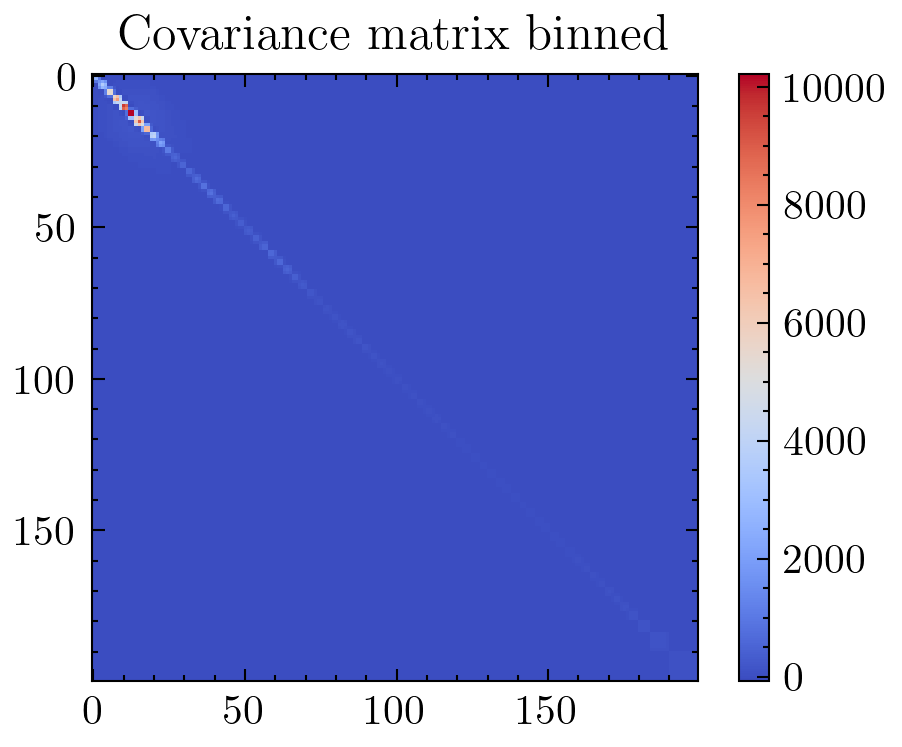

In [4]:
import matplotlib.colors as colors

cov_matrix = cov_200
plt.imshow(cov_matrix, cmap='coolwarm')
plt.colorbar()
plt.title("Covariance matrix binned")
plt.show()

In [5]:
cov_200

tensor([[ 2.6496e+03,  2.6496e+03,  9.8273e+02,  ..., -1.3473e-36,
         -1.3473e-36, -1.3473e-36],
        [ 2.6496e+03,  2.6496e+03,  9.8273e+02,  ..., -1.3473e-36,
         -1.3473e-36, -1.3473e-36],
        [ 9.8273e+02,  9.8273e+02,  1.7307e+03,  ..., -1.7904e-36,
         -1.7904e-36, -1.7904e-36],
        ...,
        [-1.3473e-36, -1.3473e-36, -1.7904e-36,  ...,  8.8400e+01,
          8.8389e+01,  8.8389e+01],
        [-1.3473e-36, -1.3473e-36, -1.7904e-36,  ...,  8.8389e+01,
          8.8400e+01,  8.8389e+01],
        [-1.3473e-36, -1.3473e-36, -1.7904e-36,  ...,  8.8389e+01,
          8.8389e+01,  8.8400e+01]])

/tmp/ipykernel_268143/2262544651.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized_cov = np.abs(cov_matrix)


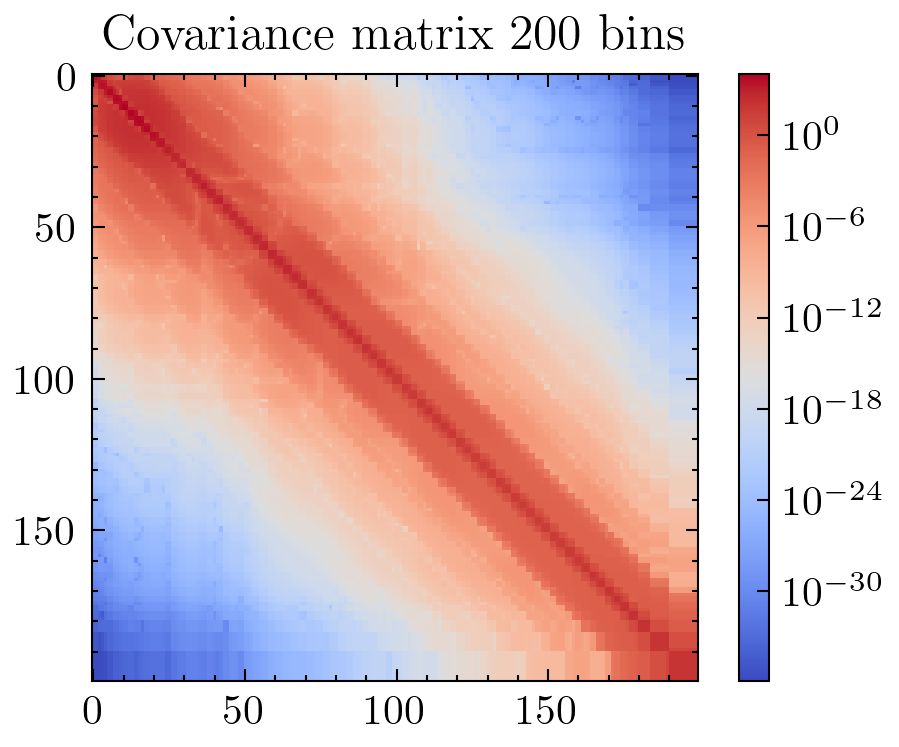

In [7]:
normalized_cov = np.abs(cov_matrix)
plt.imshow(normalized_cov, cmap='coolwarm', norm=colors.LogNorm(vmin=normalized_cov.min(), vmax=normalized_cov.max()))
plt.colorbar()
plt.title("Covariance matrix 200 bins")
plt.show()
